In [ ]:
import numpy as np
from numpy.random import multivariate_normal
import matplotlib.pyplot as plt

import parameters as p
import archive.fokker_planck as fp
import archive.monte_carlo_archive as mc

In [2]:
V_INITIAL = [5, 0]
NUMSTEPS = int(1e5)
PROCESSES = {'fp_dt': {'type': 'fokkerplanck xxi norm'}}
DT = 0.01
R = 5 
PHI = 0

In [6]:
v_store = mc.multistep_mc(v_initial=V_INITIAL, numsteps=NUMSTEPS, processes_dict=PROCESSES, dt=DT, R=R, phi=PHI)

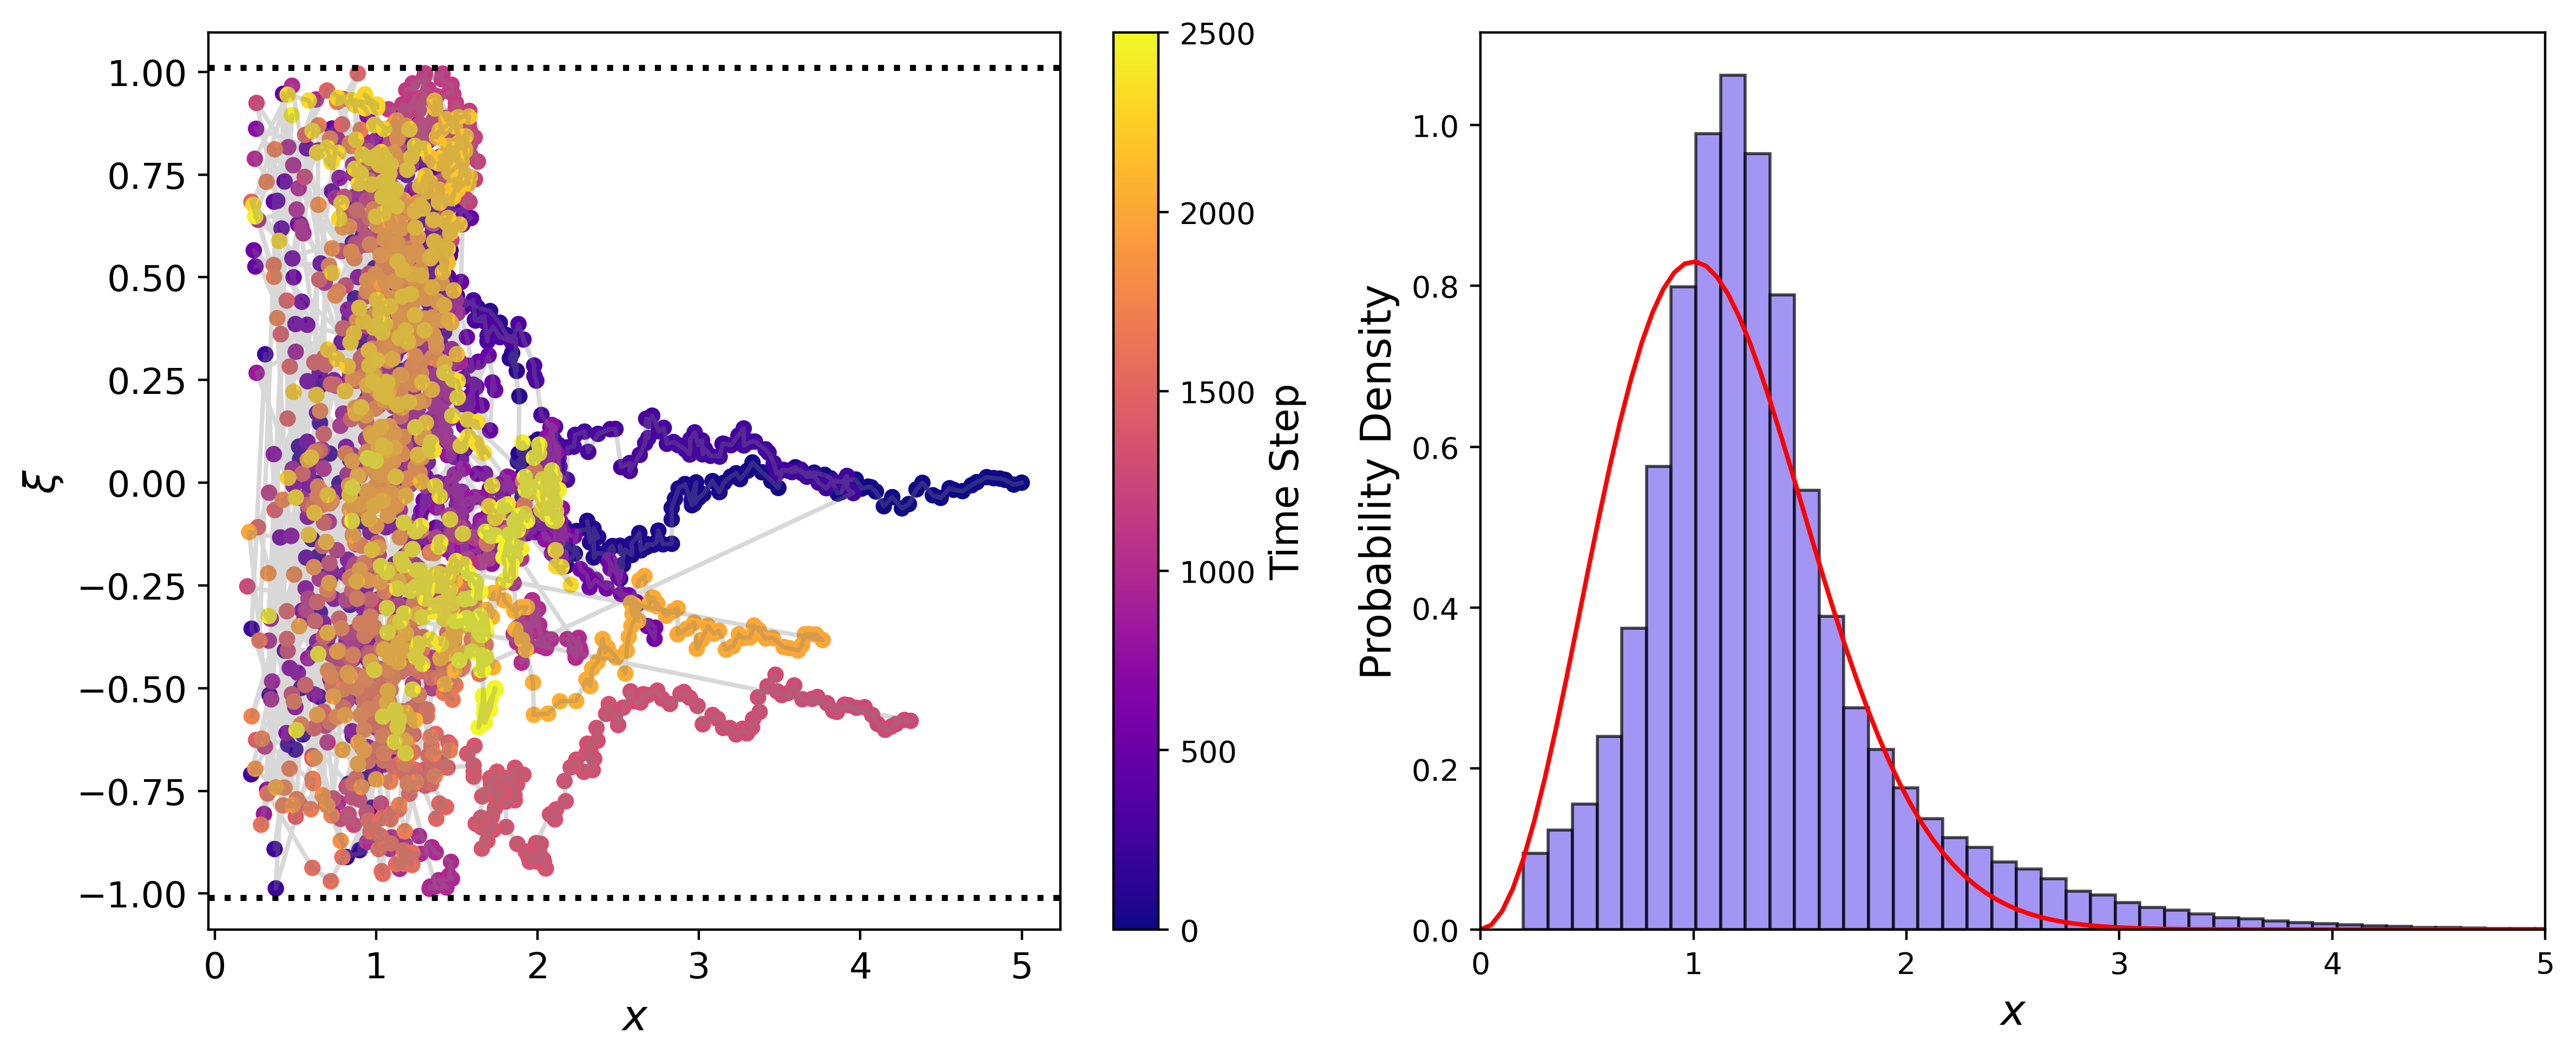

In [20]:
v_store = np.array(v_store)

x = v_store[:2500, 0]
y = v_store[:2500, 1]
t = np.arange(len(x))
colors = t

x_values = v_store[:, 0]
xmax = 5
x_line = np.linspace(0, xmax, 100)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=400)

scatter = axs[0].scatter(x, y, c=colors, cmap='plasma', s=20)
axs[0].plot(x, y, color='gray', alpha=0.3)
axs[0].set_xlabel(r'$x$', fontsize=14)
axs[0].set_ylabel(r'$\xi$', fontsize=14)
axs[0].tick_params(axis='both', labelsize=12)
axs[0].axhline(1.01, color='black', linewidth=2, linestyle=':')
axs[0].axhline(-1.01, color='black', linewidth=2, linestyle=':')

cbar = fig.colorbar(scatter, ax=axs[0])
ticks = np.arange(0, 2501, 500)
cbar.ax.tick_params(labelsize=10) 
cbar.set_ticks(ticks)
cbar.set_label('Time Step', fontsize=13)

axs[1].hist(x_values, bins=50, density=True, alpha=0.7,
            color='mediumslateblue', edgecolor='black')
axs[1].plot(x_line,
            4 / np.sqrt(np.pi) * x_line**2 * np.exp(-x_line**2),
            color='red')
axs[1].set_xlabel(r'$x$', fontsize=14)
axs[1].set_ylabel('Probability Density', fontsize=14)
axs[1].set_xlim(0, xmax)

plt.tight_layout()
plt.show()

In [ ]:
# regularization for Dxx - account for in additional drift term